# Importing Lib



In [4]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import pandas as pd

data = pd.read_csv(
    '/kaggle/input/datasets/luyucwnu/tlmuav-anomaly-detection-datasets/dataset/VIBE/ALL_FAIL_LOG_VIBE_0_Random.csv')

print(data.shape)
print(data.columns.tolist())
data.head()

(4900, 9)
['LineNo', 'TimeUS', 'IMU', 'VibeX', 'VibeY', 'VibeZ', 'Clip', 'labels', 'labels.1']


,LineNo,TimeUS,IMU,VibeX,VibeY,VibeZ,Clip,labels,labels.1
0,424709,503763414,0,0.120009,0.108398,0.148239,0,4,0
1,426871,506163287,0,0.003210,0.003270,0.002992,0,4,0
2,435120,516463332,0,0.002998,0.003317,0.002864,0,4,0
3,145047,192963617,0,0.163687,0.116775,0.247265,0,0,0
4,430951,511263746,0,0.002952,0.002766,0.002777,0,4,0


# Preprocessing and Exploring data



In [5]:
print("Dataset Shape:", data.shape)
print("\nColumns:\n", data.columns)
print("\nSample Data:\n", data.head())
print("\nMissing Values:\n", data.isnull().sum())

Dataset Shape: (4900, 9)

Columns:
 Index(['LineNo', 'TimeUS', 'IMU', 'VibeX', 'VibeY', 'VibeZ', 'Clip', 'labels',
       'labels.1'],
      dtype='object')

Sample Data:
    LineNo     TimeUS  IMU     VibeX     VibeY     VibeZ  Clip  labels  \
0  424709  503763414    0  0.120009  0.108398  0.148239     0       4   
1  426871  506163287    0  0.003210  0.003270  0.002992     0       4   
2  435120  516463332    0  0.002998  0.003317  0.002864     0       4   
3  145047  192963617    0  0.163687  0.116775  0.247265     0       0   
4  430951  511263746    0  0.002952  0.002766  0.002777     0       4   

   labels.1  
0         0  
1         0  
2         0  
3         0  
4         0  

Missing Values:
 LineNo      0
TimeUS      0
IMU         0
VibeX       0
VibeY       0
VibeZ       0
Clip        0
labels      0
labels.1    0
dtype: int64


In [6]:
print("\nData Types:\n", data.dtypes)


Data Types:
 LineNo        int64
TimeUS        int64
IMU           int64
VibeX       float64
VibeY       float64
VibeZ       float64
Clip          int64
labels        int64
labels.1      int64
dtype: object


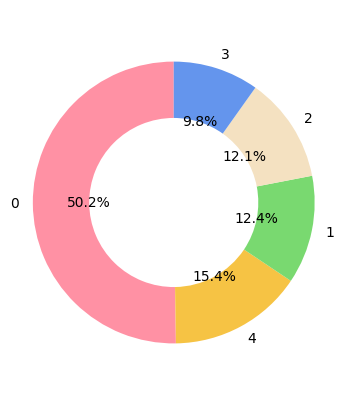

In [7]:

if 'labels' in data.columns:
    label_counts = data['labels'].value_counts()
    # Define specific colors for 5 labels
    colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]

    # Plot the donut chart
    plt.figure(figsize=(4, 5))
    plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'width': 0.4})
    plt.axis('equal')
    plt.show()



In [8]:
# Encoding Categorical Data
if 'labels' in data.columns:
    label_encoder = LabelEncoder()
    data['labels'] = label_encoder.fit_transform(data['labels'])
    print("\nLabel Encoding Complete. Classes:", label_encoder.classes_)


Label Encoding Complete. Classes: [0 1 2 3 4]


In [36]:
# Remove duplicate label column
data = data.drop(columns=['labels.1'])

# Features and target
X = data.drop(columns=['labels']).values
y = data['labels'].values

print(X.shape)
print(y.shape)

(4900, 7)
(4900,)


In [37]:
X = data.drop(columns=['labels']).values  # Features
y = data['labels'].values  # Target

In [38]:
X.shape

(4900, 7)

In [39]:
print(data.columns.tolist())

['LineNo', 'TimeUS', 'IMU', 'VibeX', 'VibeY', 'VibeZ', 'Clip', 'labels']


In [40]:
# Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# One-hot encode the labels
# One-hot encode the labels
y_encoded = to_categorical(y, num_classes=len(np.unique(y)))

In [41]:
window_size = 5

X_windows = []
y_windows = []

for i in range(len(X_scaled) - window_size + 1):
    X_windows.append(X_scaled[i:i+window_size])
    y_windows.append(y_encoded[i + window_size - 1])   # ✅ Correct

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

print(X_windows.shape)
print(y_windows.shape)

input_shape = X_windows.shape[1:]
num_classes = y_windows.shape[1]

(4896, 5, 7)
(4896, 5)


In [42]:
X_windows.shape

(4896, 5, 7)

In [43]:
for label in data['labels'].unique():
    print(f"\nValues for label: {label}")
    print(data[data['labels'] == label].head())


Values for label: 4
    LineNo     TimeUS  IMU     VibeX     VibeY     VibeZ  Clip  labels
0   424709  503763414    0  0.120009  0.108398  0.148239     0       4
1   426871  506163287    0  0.003210  0.003270  0.002992     0       4
2   435120  516463332    0  0.002998  0.003317  0.002864     0       4
4   430951  511263746    0  0.002952  0.002766  0.002777     0       4
14  387259  462163394    0  0.143049  0.153651  0.242598     0       4

Values for label: 0
    LineNo     TimeUS  IMU     VibeX     VibeY     VibeZ  Clip  labels
3   145047  192963617    0  0.163687  0.116775  0.247265     0       0
6     6546   21363951    0  0.002655  0.002836  0.002889     0       0
7   136590  183564045    0  0.161763  0.134775  0.262035     0       0
8    25476   59563665    0  0.102368  0.101971  0.117639     0       0
10  145589  193563377    0  0.160231  0.124077  0.282388     0       0

Values for label: 2
    LineNo     TimeUS  IMU         VibeX         VibeY         VibeZ  Clip  \
5   227

# Model

In [44]:
# Define the TCN Block
def TCN_Block(filters, kernel_size, dilation_rate):
    return tf.keras.Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate),
        BatchNormalization(),
        Activation('relu')
    ])

In [45]:
# Define the Attention Layer
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],), initializer="glorot_uniform", trainable=True)

    def call(self, inputs):
        u_t = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a_t = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        output = tf.reduce_sum(inputs * tf.expand_dims(a_t, -1), axis=1)
        return output

In [46]:
# Define the TCN with Attention Model
def build_tcn_attention_model(input_shape, num_classes):
    # inputs = Input(shape=input_shape)
# def build_tcn_attention_model(X_windows, num_classes):
    inputs = Input(shape=input_shape)
     # Replacing input_shape with X_windows.shape
    # TCN Layers
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=4)(inputs)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=8)(x)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=16)(x)

    # Attention mechanism
    attention_output = AttentionLayer()(x)

    # Classification
    classification = Dense(num_classes, activation='softmax')(attention_output)

    # Define and compile the model
    model = Model(inputs=inputs, outputs=classification)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=categorical_crossentropy,
                  metrics=['accuracy'])

    return model


In [47]:
# input_shape
X_windows.shape[2]

7

In [48]:
X_windows.shape[1]

5

In [49]:
X_windows.shape[0]

4896

In [22]:
X_windows.shape

(4896, 5, 8)

In [50]:
# Input shape for TCN
input_shape = (X_windows.shape[1], X_windows.shape[2])
num_classes = y_windows.shape[1]

In [51]:
# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuraciesKF = []
label_accuraciesKF = []

for train_index, val_index in kf.split(X_windows):
    print(f"\nTraining fold {fold_no}...")

    # Split data
    X_train_foldKF, X_val_foldKF = X_windows[train_index], X_windows[val_index]
    y_train_foldKF, y_val_foldKF = y_windows[train_index], y_windows[val_index]

    # Build and train the model
    # modelKF = build_tcn_attention_model(input_shape, num_classes)

    # Build and train the model
    # modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF.fit(X_train_foldKF, y_train_foldKF, epochs=50, batch_size=32, verbose=0, validation_data=(X_val_foldKF, y_val_foldKF))
   

    # Evaluate the model
    lossKF, accuracyKF = modelKF.evaluate(X_val_foldKF, y_val_foldKF, verbose=0)
    print(f"Validation Accuracy for fold {fold_no}: {accuracyKF:.4f}")
    accuraciesKF.append(accuracyKF)

    # Predictions
    y_predKF = modelKF.predict(X_val_foldKF)
    y_pred_classesKF = np.argmax(y_predKF, axis=1)
    y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

    # Accuracy per label
    label_accKF = []
    for label in range(num_classes):
        label_indicesKF = (y_true_classesKF == label)
        label_accKF.append(accuracy_score(y_true_classesKF[label_indicesKF], y_pred_classesKF[label_indicesKF]))
    label_accuraciesKF.append(label_accKF)

    fold_no += 1



Training fold 1...
Validation Accuracy for fold 1: 0.8388
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Training fold 2...
Validation Accuracy for fold 2: 0.7794
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training fold 3...
Validation Accuracy for fold 3: 0.9244
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training fold 4...
Validation Accuracy for fold 4: 0.7926
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training fold 5...
Validation Accuracy for fold 5: 0.8958
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [52]:
modelKF.summary()

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 5, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_27 (Sequential)      │ (None, 5, 64)          │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_28 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_29 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_9               │ (None, 64)             │         4,224 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,521 (365.32 KB)

 Trainable params: 31,045 (121.27 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 62,092 (242.55 KB)

In [53]:
# Calculate average accuracy
average_accuracyKF = np.mean(accuraciesKF)
print(f"\nAverage Accuracy across all folds: {average_accuracyKF:.4f}")


Average Accuracy across all folds: 0.8462


In [54]:
# Average accuracy per label
label_accuraciesKF = np.mean(label_accuraciesKF, axis=0)
for idx, acc in enumerate(label_accuraciesKF):
    print(f"Label {idx} Accuracy: {acc:.4f}")

Label 0 Accuracy: 0.9634
Label 1 Accuracy: 0.9402
Label 2 Accuracy: 0.3711
Label 3 Accuracy: 0.5111
Label 4 Accuracy: 0.9739


In [55]:
# Evaluate the last fold predictions
y_predKF = modelKF.predict(X_val_foldKF)
y_pred_classesKF = np.argmax(y_predKF, axis=1)
y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [56]:
import pandas as pd
import numpy as np

feature_names = ["LineNo", "TimeUS", "IMU", "VibeX", "VibeY", "VibeZ", "Clip"]


# Step 1: Get Model Predictions
y_pred_probs = modelKF.predict(X_windows, verbose=0)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Find misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

print("Total Misclassified Windows:", len(mismatch_indices))

# Extract the last time step from each misclassified window
X_last = X_windows[mismatch_indices, -1, :]

# Create DataFrame
df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add labels
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

# Add original window index
df_mismatches.insert(0, "Window_Index", mismatch_indices)

print(df_mismatches)

# Optional: Save to CSV
df_mismatches.to_csv("Misclassified_Windows.csv", index=False)




Total Misclassified Windows: 512
     Window_Index    LineNo    TimeUS  IMU     VibeX     VibeY     VibeZ  \
0               1  0.053241  0.057116  0.0 -0.347025 -0.468797 -0.316966   
1              14 -0.817298 -0.807405  0.0  0.090811  0.134707  0.128109   
2              44  0.070951  0.074686  0.0 -0.347025 -0.468797 -0.316966   
3              55  0.132487  0.135834  0.0 -0.347025 -0.468797 -0.316966   
4              62  0.802312  0.800746  0.0 -0.031816 -0.046932 -0.312197   
..            ...       ...       ...  ...       ...       ...       ...   
507          4864  0.615318  0.615188  0.0 -0.135724 -0.178759 -0.312478   
508          4870  0.830672  0.828861  0.0 -0.019105 -0.057585 -0.312356   
509          4871  0.084355  0.088041  0.0 -0.347025 -0.468797 -0.316966   
510          4882  0.764743  0.763492  0.0 -0.005587 -0.047227 -0.311960   
511          4891  0.062458  0.066250  0.0 -0.347025 -0.468797 -0.316966   

     Clip  Actual_Label  Predicted_Label  
0     0.0  

In [57]:
import pandas as pd
import numpy as np

feature_names = ["LineNo", "TimeUS", "IMU", "VibeX", "VibeY", "VibeZ", "Clip"]
# Predictions
y_pred_probs = modelKF.predict(X_windows, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

# Take only the last time step
X_last = X_windows[mismatch_indices, -1, :]

df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

df_mismatches.insert(0, "Window_Index", mismatch_indices)
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

print(df_mismatches)

     Window_Index    LineNo    TimeUS  IMU     VibeX     VibeY     VibeZ  \
0               1  0.053241  0.057116  0.0 -0.347025 -0.468797 -0.316966   
1              14 -0.817298 -0.807405  0.0  0.090811  0.134707  0.128109   
2              44  0.070951  0.074686  0.0 -0.347025 -0.468797 -0.316966   
3              55  0.132487  0.135834  0.0 -0.347025 -0.468797 -0.316966   
4              62  0.802312  0.800746  0.0 -0.031816 -0.046932 -0.312197   
..            ...       ...       ...  ...       ...       ...       ...   
507          4864  0.615318  0.615188  0.0 -0.135724 -0.178759 -0.312478   
508          4870  0.830672  0.828861  0.0 -0.019105 -0.057585 -0.312356   
509          4871  0.084355  0.088041  0.0 -0.347025 -0.468797 -0.316966   
510          4882  0.764743  0.763492  0.0 -0.005587 -0.047227 -0.311960   
511          4891  0.062458  0.066250  0.0 -0.347025 -0.468797 -0.316966   

     Clip  Actual_Label  Predicted_Label  
0     0.0             2                0  
1

In [58]:
# Step 1: Identify correctly classified windows
correct_indices = np.where(y_true_labels == y_pred_labels)[0]

# Step 2: Extract the last time step of each correctly classified window
X_last = X_windows[correct_indices, -1, :]

# Step 3: Create DataFrame
df_correct = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add metadata
df_correct.insert(0, "Window_Index", correct_indices)
df_correct["Actual_Label"] = y_true_labels[correct_indices]
df_correct["Predicted_Label"] = y_pred_labels[correct_indices]

# Step 4: Save to CSV
df_correct.to_csv("correctly_classified.csv", index=False)

# Display
print(df_correct.head())

   Window_Index    LineNo    TimeUS  IMU      VibeX      VibeY     VibeZ  \
0             0  1.657880  1.653318  0.0  -0.338938  -0.457494 -0.312241   
1             2 -1.682665 -1.790007  0.0  -0.339752  -0.457206 -0.312050   
2             3 -0.659073 -0.649962  0.0   0.096259   0.082086  0.129006   
3             4 -1.533665 -1.521515  0.0  -0.066504  -0.051998 -0.116750   
4             5  0.552750  0.552635  0.0  15.760124  13.360660  4.666588   

   Clip  Actual_Label  Predicted_Label  
0   0.0             4                4  
1   0.0             0                0  
2   0.0             0                0  
3   0.0             0                0  
4   0.0             3                3  


In [59]:
df_mismatches.to_csv("misclassified_samples.csv", index=False)
print("CSV file 'misclassified_samples.csv' saved successfully!")


CSV file 'misclassified_samples.csv' saved successfully!


In [60]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true_classesKF, y_pred_classesKF,digits = 4))


Classification Report:

              precision    recall  f1-score   support

           0     0.8518    0.9709    0.9074       515
           1     0.8704    0.8704    0.8704       108
           2     0.9841    0.5962    0.7425       104
           3     1.0000    0.7191    0.8366        89
           4     1.0000    0.9632    0.9812       163

    accuracy                         0.8958       979
   macro avg     0.9413    0.8239    0.8676       979
weighted avg     0.9060    0.8958    0.8917       979



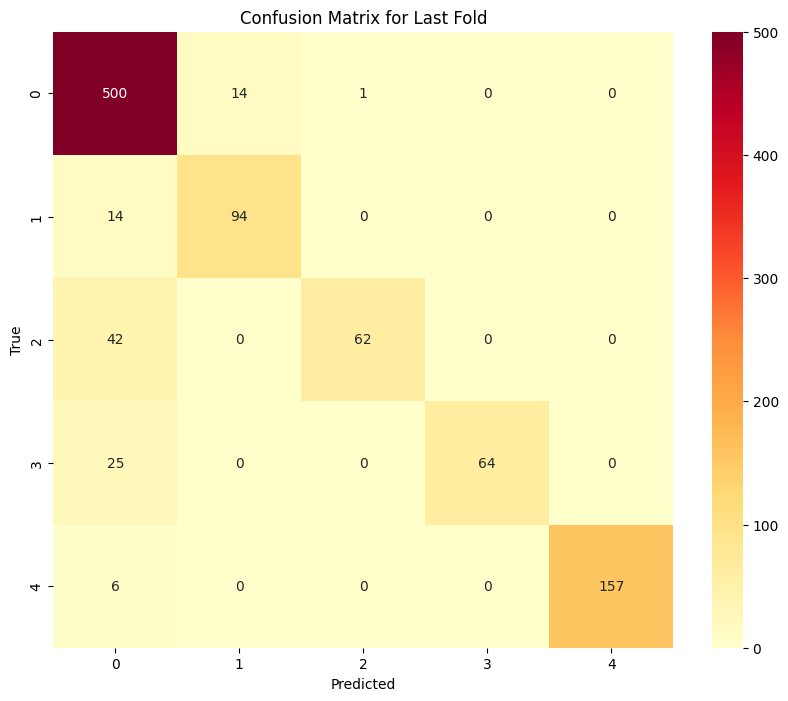

In [61]:
# Confusion Matrix
conf_matrixKF = tf.math.confusion_matrix(y_true_classesKF, y_pred_classesKF)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrixKF, annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix for Last Fold')
plt.show()


Label Distribution:
 labels
0    10147
4     3440
2     3092
1     2846
3     2072
Name: count, dtype: int64


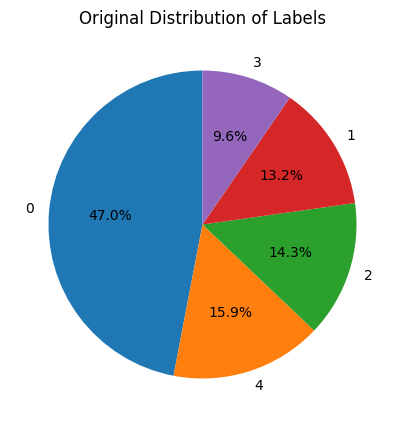

In [36]:
if 'labels' in data.columns:
    label_countsKF = data['labels'].value_counts()
    print("\nLabel Distribution:\n", label_countsKF)
    plt.figure(figsize=(5, 5))
    plt.pie(label_countsKF, labels=label_countsKF.index, autopct='%1.1f%%', startangle=90)
    plt.title('Original Distribution of Labels')
    plt.show()

0    1964
4     709
1     655
2     606
3     385
Name: count, dtype: int64


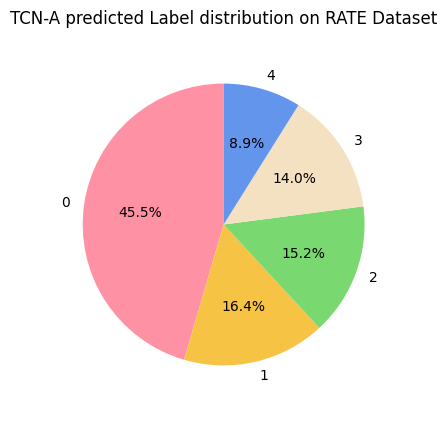

In [37]:

# Get the label distribution after training
# Get the predicted labels after training
class_counts = pd.Series(y_pred_classesKF).value_counts()
print(class_counts)
# Plot pie chart of predicted labels
plt.figure(figsize=(4, 5))
colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]
plt.pie(pd.Series(y_pred_classesKF).value_counts(), labels=label_encoder.classes_, autopct='%1.1f%%', startangle=90,colors=colors)
plt.axis('equal')
plt.title('TCN-A predicted Label distribution on RATE Dataset')
plt.show()